In [1]:
# Ch2

import pymc as pm
import pytensor
import numpy as np

from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

plt.style.use("ggplot")
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)

In [2]:
with pm.Model() as model:
    # a data_generator function, generates a Poisson with lambda = 1 and an initval comes from an Exponential
    parameter = pm.Exponential('lambda_exp', 1.0, initval=rng.exponential(1))
    data_generator = pm.Poisson('data_generator', parameter) 

__random.default_rng(seed=Opt)__
- numpy, makes a Generator only, call it with .random or a distribution.
- http://numpy.org/doc/stable/reference/random/generator.html

__initval__

- All PyMC variables have an initial value, if you don't define an `initval` paramater, PyMC will automatically initialize it for you.

- In PyMC, initval defines the starting point or strategy for Markov chain Monte Carlo (MCMC) samplers. You can specify it directly when instantiating a distribution (like pm.Normal), set it at the model level with model.set_initval, or pass a dictionary of strategies to pm.sample.

- The initval parameter is used only for the model, as the starting point for sampling if no other start is specified. It will not change as a result of sampling.

- This can be helpful (and be also helpful to debug, as the PyTensor document reference said above) if you are using a more unstable prior that may require a better starting point.

- By default, PyMC uses the moments of a distribution (typically the mean) as the initial value. You can use the initval argument to pass specific scalar values, arrays, or predefined strategies.

- initval = "moment" will usually select the mean.  initval = "prior" draws a random sample directly from the defined prior.

In [3]:
with model:
    data_plus_one = data_generator + 1

In [4]:
# initial_values attribute no longer works  .. use initial_point() or basic_RVs() or root() functions
model.initial_point()

{'lambda_exp_log__': array(0.36864242), 'data_generator': array(1)}

In [5]:
# this one is probably most useful
model.basic_RVs

[lambda_exp ~ Exponential(f()), data_generator ~ Poisson(lambda_exp)]

In [6]:
with pm.Model() as model_exp:
    theta = pm.Exponential('theta', 2.0)
    data_generator = pm.Poisson('data_generator', theta)

In [7]:
model_exp.initial_point()

{'theta_log__': array(-0.69314718), 'data_generator': array(0)}

In [8]:
with pm.Model() as ab_testing:
    p_A = pm.Uniform('P(A)', 0, 1)
    p_B = pm.Uniform('P(B)', 0, 0)

In [9]:
ab_testing.basic_RVs

[P(A) ~ Uniform(0, 1), P(B) ~ Uniform(0, 0)]

In [10]:
ab_testing.initial_point()

{'P(A)_interval__': array(0.), 'P(B)_interval__': array(nan)}

__Stochastic Variables__

- https://www.pymc.io/projects/docs/en/v5.4.0/api/distributions.html 
- Initializing a stochastic, or random, variable requires a name argument, plus additional parameters that are class specific.
- The name attribute is used to retrieve the posterior distribution later in the analysis, so it is best to use a descriptive name.

In [11]:
with pm.Model() as sample_model:
    some_var = pm.DiscreteUniform('my_uniform_var', 0, 4)

__multivariable with `shape`__

- For multivariable problems, rather than creating a Python array of stochastic variables, addressing the `shape` keyword in the call to a stochastic variable creates multivariate array of (independent) stochastic variables.
- The `shape` argument also solves the annoying case where you may have many variables you wish to model. Instead of creating arbitrary names and variables for each one

In [12]:
with pm.Model() as many_betas:
    betas = pm.Uniform('betas', 0, 1, shape=4)

In [13]:
many_betas.basic_RVs

[betas ~ Uniform(0, 1)]

In [14]:
# resulting variables organized in arrays
many_betas.initial_point()

{'betas_interval__': array([0., 0., 0., 0.])}

__Deterministic Variables__

- https://www.pymc.io/projects/docs/en/v5.7.1/api/generated/pymc.Deterministic.html
- If we want a deterministic variable to actually be tracked by our sampling, we need to define it explicitly as a named deterministic variable with the `Deterministic()` constructor.
- Generally used to record an intermediary result.  Has to be some calculation or manipulation of other variable(s) in the model, otherwise error.

In [15]:
with pm.Model() as another_model:
    beta_1 = pm.Uniform('beta_1', 0, 1)
    beta_2 = pm.Uniform('beta_2', 0, 2)
    my_det_variable = pm.Deterministic('det_var', beta_1 * beta_2)

In [16]:
# we can reference other functions to perform these calculations

def subtract(x,y):
    return x-y

with pm.Model() as model_2:
    stochastic_1 = pm.Uniform('U_1', 0, 1)
    stochastic_2 = pm.Uniform('U_2', 0, 1)
    det_1 = pm.Deterministic('delta', subtract(stochastic_1, stochastic_2))


__pytensor__

https://pytensor.readthedocs.io/en/latest/index.html


- PyMC is a collection of pytensor expressions for probability distributions, and inference algorithms to compute probabilities and gradients (in a nutshell).  Sometimes we use pytensor functions directly. 
- `pytensor` notation is very similar to numpy. but while numpy performs calculations immediately, pytensor is lazy-evaluated and only executes when `eval()` is called.
- pytensor is optimized to work with multidimensional arrays (tensors) and builds a "compute graph" that computes at scale, can compile to C, or compile to run on the GPU.  
- this is reassuring: "Much of the documentation hasn’t been updated and is simply the old Theano documentation."

In [17]:
import pytensor.tensor as pt

In [18]:
# here we use pytensor's stack() function to combine two arrays into a 2-element vector that the Categorical() class will understand.

with pm.Model() as pytensor_test:
    p1 = pm.Uniform('p', 0, 1)
    p2 = 1 - p1
    p = pt.stack([p1, p2])

    assignment = pm.Categorical('assignment', p)

pytensor_test.basic_RVs

[p ~ Uniform(0, 1), assignment ~ Categorical(f(p))]

Including Observations in the Model

In [19]:
with pm.Model() as model:
    lambda_1 = pm.Exponential("lambda_1", 1.0,initval=0.5)
    lambda_2 = pm.Exponential("lambda_2", 1.0,initval=0.5)
    tau = pm.DiscreteUniform("tau", lower=0, upper=10)

__draw__

- https://www.pymc.io/projects/docs/en/latest/api/generated/pymc.draw.html
- draw samples from a variable or list of variables
- apparently don't need to call the particular Model(), just the named variable .. "pm.draw evaluates independent PyTensor computational subgraphs, meaning it does not rely on a full Model container to function."

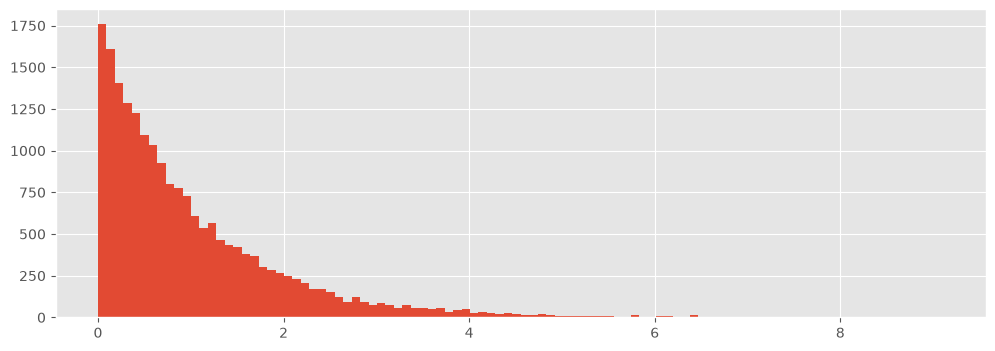

In [20]:
samples = pm.draw(lambda_1, draws=20000)

figsize(12,4)
plt.hist(samples, bins=100)
plt.show()


__observed__

Without the `observed` keyword, PyMC is just a simulator generating random numbers based on your formulas.  Adding `observed` turns it into an inference engine. allowing the model to look at past data and learn the hidden rules that generated it.

When you create a random variable in PyMC, it can be one of two things:

- Unobserved (Parameters): These are the unknowns you want to learn about (e.g., an unknown rate, a true mean, or a slope). PyMC will constantly change and test different values for these variables during sampling.
- Observed (Data): This is the fixed reality you collected from the real world. By passing your data to the `observed` keyword, you tell PyMC: "This variable cannot change. It is locked to these exact data points."

When you apply `observed=data` to a variable, PyMC changes how it treats that variable in three major ways:

- PyMC freezes the variable / distribution to match the shape and values of your observed data
- PyMC turns the distribution into a `likelihood`.  Instead of asking 'what values might this variable take', it asks "given my current guesses for the unknown parameters, how likely is it I would see these specific data?"
- PyMC removes it from the output and not waste memory sampling from it.

In [21]:
data = np.array([10,5])
with model:
    fixed_variable = pm.Poisson('fxd', 1, observed=data)

model.basic_RVs

[lambda_1 ~ Exponential(f()),
 lambda_2 ~ Exponential(f()),
 tau ~ DiscreteUniform(f(), f()),
 fxd ~ Poisson(1)]

In [22]:
model.initial_point()

{'lambda_1_log__': array(-0.69314718),
 'lambda_2_log__': array(-0.69314718),
 'tau': array(5)}

__Modeling Approaches__

Working the Ch1 example in reverse..

In [23]:
# specify when user behavior switches by sampling from DiscreteUniform distribution 
tau = np.random.randint(0,75)
tau

9

In [24]:
# draw lambda_1 and lambda_2 from an Exp(a) distribution
alpha = 0.05
lambda_1, lambda_2 = np.random.exponential(scale = 1/alpha, size=2)
print(lambda_1, lambda_2)

10.615467508561906 5.994131361156935


In [25]:
# for days before tau, generate sample Poisson(lambda_1), for after sample Poisson(lamda_2)

# use stats.poisson
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.poisson.html
# and .rvs generates random samples given a mu and size (number of samples to return)

# and numpy's r_ function concatenates arrays (r_ for row, c_ for column)
# https://numpy.org/doc/2.3/reference/generated/numpy.r_.html

# stats.poisson.rvs(mu=lambda_2, size=10)

data = np.r_[stats.poisson.rvs(mu=lambda_1, size=tau), stats.poisson.rvs(mu=lambda_2, size=75-tau)]

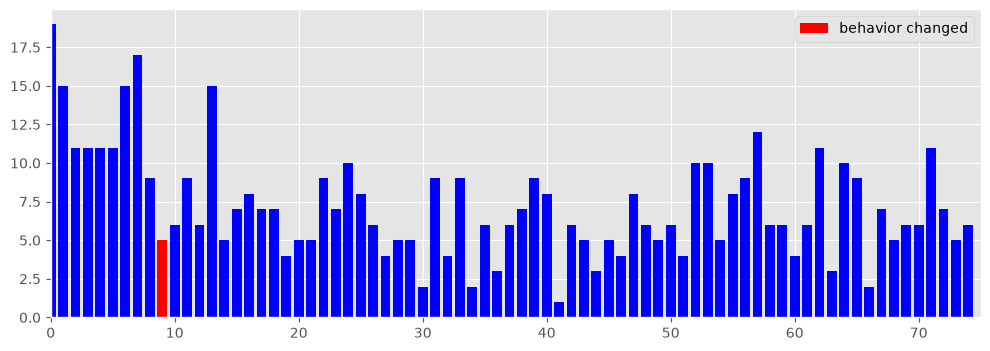

In [26]:
plt.bar(np.arange(75), data, color="blue")
plt.bar(tau, data[tau], color="red", label="behavior changed")
plt.xlim(0,75)
plt.legend()

__Bayesian A/B Testing__

This is an example of a Bayesian approach to an A/B test (versus frequentist approaches examining difference-of-means or proportions tests.) 

Assume there is a probability that visitors to Site A eventually purchase from the site.  If we have $N$ total site visitors, and $n$ eventually purchase, our observed conversion rate $\frac{n}{N}$ won't necessarily equal the true conversion rate $P(A)$ in the same way that observed six-sided dice rolls won't necessarily equal the true probability of 1/6. 

With a Bayesian model, we infer the true frequency using an appropriate prior and observed data.  We begin by assigning prior distributions to our unknown quantities - in this case, we don't have any strong conviction about the true conversion rate, so we assume $P(A)$ is uniform over [0,1]:

In [27]:
# https://www.pymc.io/projects/docs/en/v5.4.0/api/distributions/generated/pymc.Uniform.html
# note we use continuous Uniform, not discrete ..

with pm.Model() as model:
    p = pm.Uniform('p', lower = 0, upper = 1)

Next we would add our actual observations to the model.  Since this is just an example, we'll generate 1500 observations and assume the real $P(A)$ is 0.05.  In actual practice of course we'd just have the observations and not know what the real P(A) is.

In [28]:
p_obs = 0.05 # the real P(A), unknown to us
N = 1500

# run Bernoulli simulation using stats.bernoulli.rvs, returns booleans
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bernoulli.html#scipy.stats.bernoulli
obs = stats.bernoulli.rvs(p = p_obs, size = N) 

print(obs)
print(np.sum(obs)) # number of conversions
print(np.mean(obs)) # the observed P(A) 

[1 0 0 ... 0 0 0]
83
0.05533333333333333


In [29]:
# add the observations to the model
# note we declare our assumption it comes from a Bernoulli, but with p from a Uniform dist
# i.e. "what is the likelihood we got these P(A)=0.05 results if real P(A) is uniform"

with model:
    observed = pm.Bernoulli('obs', p, observed=obs)

In [30]:
with model:
    step = pm.Metropolis()
    trace = pm.sample(18000, step=step, chains=3)

Multiprocess sampling (3 chains in 3 jobs)
Metropolis: [p]


Output()

Sampling 3 chains for 1_000 tune and 18_000 draw iterations (3_000 + 54_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


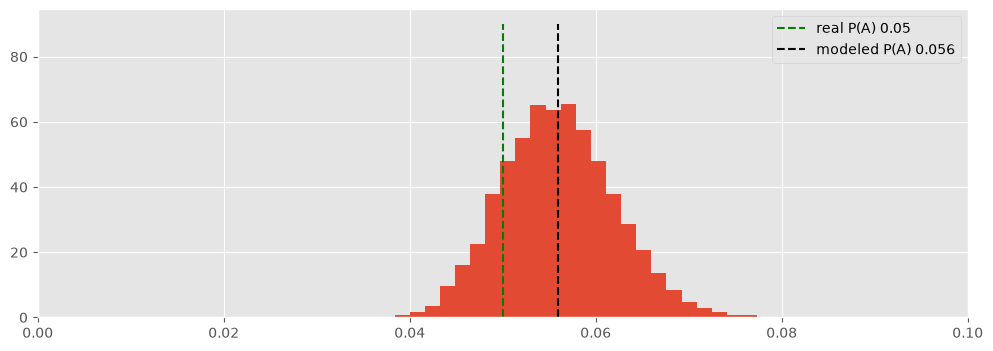

In [31]:
# plot the posterior distribution, i.e. the true P(A)

# concatenate the chains
combined = np.concatenate(trace.posterior.p.data[:,1000:])
plt.hist(combined, bins=30, density=True)
plt.vlines(p_obs, 0, 90, linestyle='--', color='green', label=f'real P(A) {p_obs}')
plt.vlines(np.mean(combined), 0, 90, linestyle='--', color='black', label=f'modeled P(A) {np.mean(combined).round(4)}')
plt.xlim([0,.1])
plt.legend()
plt.show()

# noting there is still a lot of variance between runs .. and still a frequentist aspect with larger observed datasets

array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

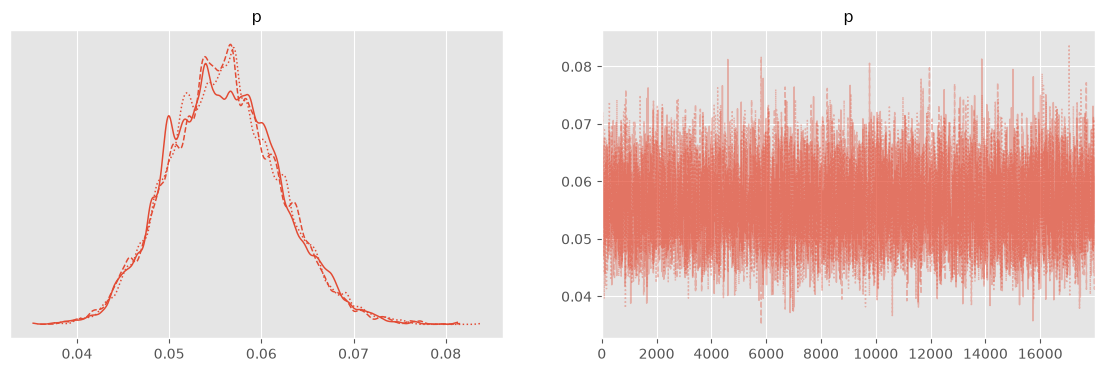

In [32]:
# trace analysis with arviz
# https://python.arviz.org/en/v0.22.0/user_guide/index.html

az.plot_trace(trace, figsize=(14,4))

__A and B Together__

We'll run both A and B in the same model, and use a deterministic variable to examine the differences.

In [39]:
# generate some sample observations

p_A_true = 0.05 # real p_A, unknown
N_A = 1500

p_B_true = 0.04 # real p_B, unknown
N_B = 750 # uneven samples, but OK for Bayesian

obs_A = stats.bernoulli.rvs(p_A_true, size=N_A)
obs_B = stats.bernoulli.rvs(p_B_true, size=N_B)

In [40]:
with pm.Model() as model:
    p_A = pm.Uniform('p_A', 0, 1)
    p_B = pm.Uniform('p_B', 0, 1)

    delta = pm.Deterministic('delta', p_A - p_B)

    observed_A = pm.Bernoulli('obs_A', p_A, observed = obs_A)
    observed_B = pm.Bernoulli('obs_B', p_B, observed = obs_B)

    step = pm.Metropolis()
    trace = pm.sample(20000, step=step, chains=2)



Multiprocess sampling (2 chains in 2 jobs)
CompoundStep
>Metropolis: [p_A]
>Metropolis: [p_B]


Output()

Sampling 2 chains for 1_000 tune and 20_000 draw iterations (2_000 + 40_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [41]:
# concat the chains of posterior distributions

p_A_samples = np.concatenate(trace.posterior.p_A.data[:,1000:])
p_B_samples = np.concatenate(trace.posterior.p_B.data[:,1000:])
delta_samples = np.concatenate(trace.posterior.delta.data[:,1000:])

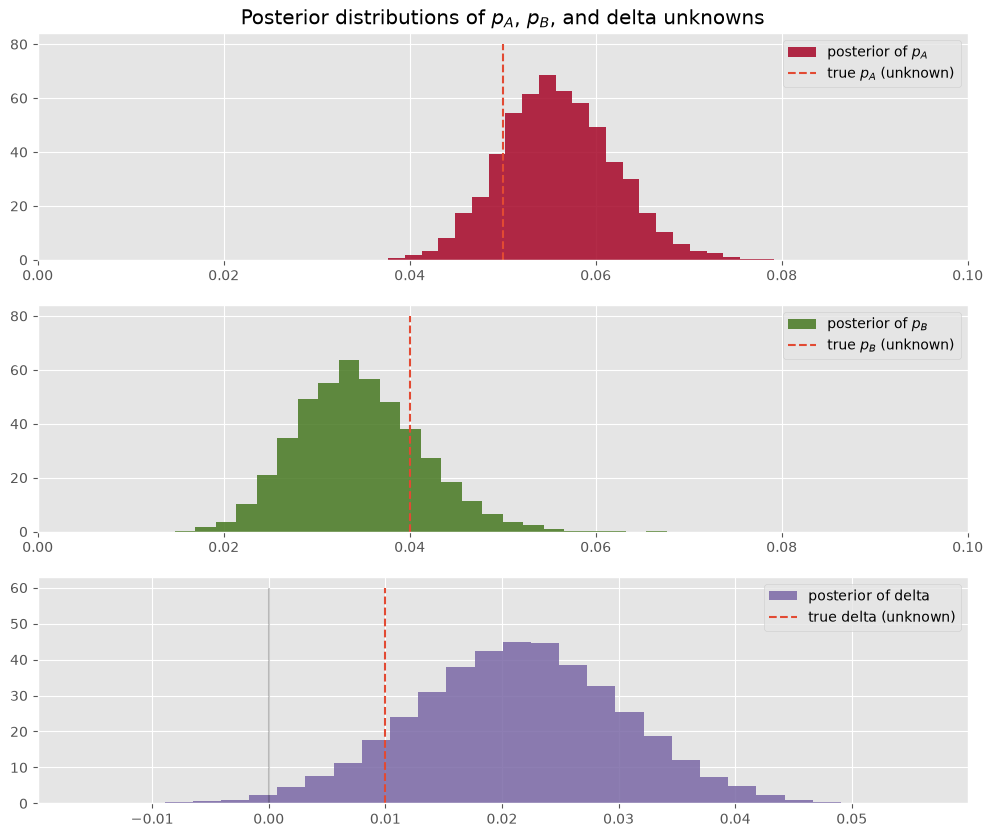

In [42]:
# histogram of posteriors

figsize(12,10)
ax = plt.subplot(311)

plt.xlim(0, .1)
plt.hist(p_A_samples, histtype='stepfilled', bins=25, alpha=0.85, label="posterior of $p_A$", color="#A60628", density=True)
plt.vlines(p_A_true, 0, 80, linestyle="--", label="true $p_A$ (unknown)")
plt.title("Posterior distributions of $p_A$, $p_B$, and delta unknowns")
plt.legend()

ax = plt.subplot(312)

plt.xlim(0, .1)
plt.hist(p_B_samples, histtype='stepfilled', bins=25, alpha=0.85, label="posterior of $p_B$", color="#467821", density=True)
plt.vlines(p_B_true, 0, 80, linestyle="--", label="true $p_B$ (unknown)")
plt.legend()

ax = plt.subplot(313)
plt.hist(delta_samples, histtype='stepfilled', bins=30, alpha=0.85, label="posterior of delta", color="#7A68A6", density=True)
plt.vlines(p_A_true - p_B_true, 0, 60, linestyle="--", label="true delta (unknown)")
plt.vlines(0, 0, 60, color="black", alpha=0.2)
plt.legend()

__Binomial Distribution__

